In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from cbm.data.utils import sample_mrf_prec
from cbm.estimation import estimate_bottleneck_and_mechanism_fcts
from cbm.eval import linear_bottleneck_eval
from cbm import GaussianLangevinMechanism, MacroCausalVar, SCBM

In [2]:
def get_rgb_color(x, y):
    hue = (np.arctan2(y, x) + np.pi) / (2*np.pi)
    saturation = np.sqrt(x ** 2 + y ** 2)
    # Standardize
    saturation = saturation / np.max(saturation)
    value = np.ones_like(hue)

    colors = matplotlib.colors.hsv_to_rgb(np.stack((hue, saturation, value)).T)

    return colors

In [ ]:
# 1. Define (simple, two node) model
# 2. Plot bottleneck space with some color pattern
# 3. Map points in bottleneck space back to observation space, mapping color to X points
# 4. Estimate bottleneck
# 5. Apply map form 3., visualize results to show correspondence of points and how space "warps"

# New things to check:
# - Does the invertible map between gt and learned bottleneck always have to be linear for linear bottleneck fcts?
# - Check the identifiability metric, compare different seed cases
# - Why do things look harder to interpret when we dont have an anti diagonal M?
# - Why are the sampled P matrices different for different ways of calling the function?

# 6.11.25: IDentifiability metric helps: weird cases had low scores. Next up: put everything into a wrapper function, output both plots directly. args: seed, lin vs non-nonlin


## Linear

In [55]:
# Define two node SCBM

# seed = 42  # +
seed = 90872  # -
# seed = 0  # +
# seed = 666  # +
# seed = 720289
rs = np.random.RandomState(seed=seed)

# Shared vars
n_micro = 4  # nr of internal nodes

M = np.ones((n_micro, n_micro))  # internal node sparsity mask
M[0,3] = M[1,2] = M[2,1] = M[3,0] = 0

print(f"M: {M}")

# Node 1
P1 = sample_mrf_prec(dim=n_micro, M=M, rs=rs)  # precision matrix
mech1 = GaussianLangevinMechanism(mu=np.zeros(n_micro), E=np.linalg.inv(P1))

print(f"P1: {P1}")

X1 = MacroCausalVar(parents=None, bottleneck_fcts=None, mechanism=mech1, d=n_micro)

# Node 2
P2 = sample_mrf_prec(dim=n_micro, M=M, rs=rs)  # precision matrix

# Sample linear bottleneck function
d_bottleneck = 2
w_bn = rs.uniform(size=(n_micro, d_bottleneck))
# Make sure rank is correct
while np.linalg.matrix_rank(w_bn) < d_bottleneck:
    w_bn = rs.uniform(size=(n_micro, d_bottleneck))

def f_bn(x):
    return x @ w_bn

# Sample linear mechanism function
w_mech = rs.uniform(size=(d_bottleneck, n_micro))
while np.linalg.matrix_rank(w_mech) < d_bottleneck:
    w_mech = rs.uniform(size=(d_bottleneck, n_micro))

def f_mech(x):
    return x @ w_mech

mech2 = GaussianLangevinMechanism(mu=f_mech, E=np.linalg.inv(P2))

X2 = MacroCausalVar(parents=[X1], bottleneck_fcts=[f_bn], mechanism=mech2, d=n_micro)

variables = np.empty(2, dtype=object)
variables[0] = X1
variables[1] = X2

A = np.asarray([[0, 1],
                [0, 0]])
d_bottleneck_matrix = np.empty_like(A, dtype=object)
d_bottleneck_matrix[0, 1] = 2

scbm = SCBM(variables=variables, A=A, d_bottleneck_matrix=d_bottleneck_matrix, seed=seed)

M: [[1. 1. 1. 0.]
 [1. 1. 0. 1.]
 [1. 0. 1. 1.]
 [0. 1. 1. 1.]]
P1: [[0.29210831 0.08461221 0.06676375 0.        ]
 [0.08461221 0.88098488 0.         0.45758071]
 [0.06676375 0.         0.9953463  0.94973906]
 [0.         0.45758071 0.94973906 1.21015286]]


In [64]:
n_samples = 10000
samples, bn_samples = scbm.sample(size=n_samples)

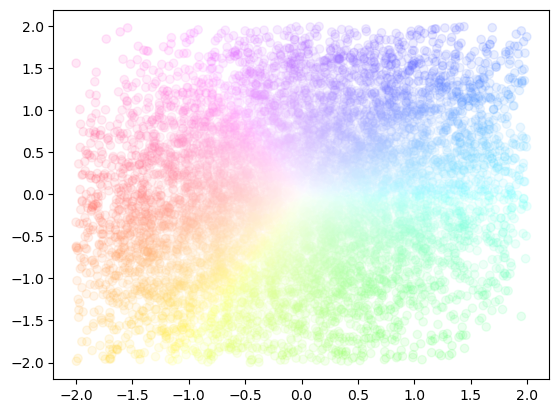

In [65]:
# Sample lots of points, push forward to bottleneck space, only plot some bounded to set (to make plot cleaner)
n_samples = 10000

samples_new, bn_samples_new = scbm.sample(size=n_samples)

# Get indices of points in bottleneck space within some bounds
bounds = [-2, 2, -2, 2]  # x_min, x_max, y_min, y_max
indices = np.where((bn_samples_new[0, 1][:, 0] >= bounds[0]) &
                   (bn_samples_new[0, 1][:, 0] <= bounds[1]) &
                   (bn_samples_new[0, 1][:, 1] >= bounds[2]) &
                   (bn_samples_new[0, 1][:, 1] <= bounds[3]))[0]

# Select only points within bounds
bn_samples_bounded = bn_samples_new[0, 1][indices]

fig, ax = plt.subplots()

ax.scatter(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)

In [66]:
# Estimate bottleneck
estimated_bn_fcts, _ = estimate_bottleneck_and_mechanism_fcts(SCBM=scbm, samples=samples, mode='linear')

In [67]:
# Apply estimated bottleneck function
estimated_bn_samples = estimated_bn_fcts[0, 1](samples[0])

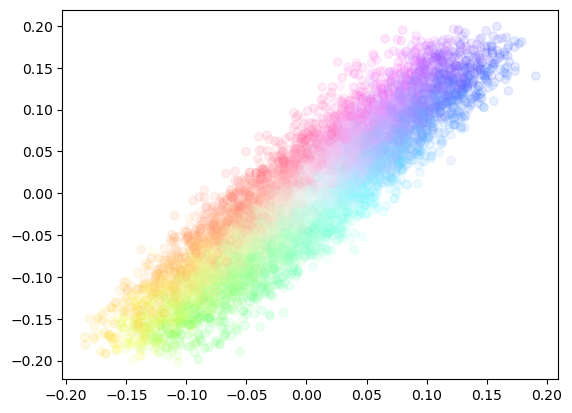

In [68]:
# Select bounded samples in observation space
samples_bounded = samples_new[0][indices]

# Push forward thorugh learned bottleneck function
bn_samples_learned = estimated_bn_fcts[0, 1](samples_bounded)

fig, ax = plt.subplots()

ax.scatter(bn_samples_learned[:, 0], bn_samples_learned[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)

In [69]:
# Sanity check: calculate id metric
estimated_bn_samples_matrix = np.empty_like(estimated_bn_fcts, dtype=object)
estimated_bn_samples_matrix[0, 1] = estimated_bn_samples
eval_matrix = linear_bottleneck_eval(estimated_bn_samples_matrix, bn_samples)

print(np.mean(eval_matrix[eval_matrix != None]))

0.9451593661534807


In [15]:
# Let's repeat the above but using the functions we define for other experiements

from cbm.data import SCBMSampler

# Sample a linear SCBM with two (macro) nodes
seed = 3948
rs = np.random.RandomState(seed=seed)

sampler = SCBMSampler(seed=seed,
                      d_macro=2,
                      d_micro=4,
                      d_bottleneck=2,
                      bottleneck_mode='linear',
                      mech_mode='linear',
                      p=1.0)

scbm_lin = sampler.sample()

n_samples = 10000
samples, bn_samples = scbm_lin.sample(size=n_samples)

# Estimate bottleneck
estimated_bn_fcts, _ = estimate_bottleneck_and_mechanism_fcts(SCBM=scbm_lin, samples=samples, mode='linear')

# Apply estimated bottleneck function
estimated_bn_samples = estimated_bn_fcts[0, 1](samples[0])

# Sample lots of points, push forward to bottleneck space, only plot some bounded to set (to make plot cleaner)
n_samples_plot = 10000

samples_plot, bn_samples_plot = scbm_lin.sample(size=n_samples_plot)

# Get indices of points in bottleneck space within some bounds
bounds = [-2, 2, -2, 2]  # x_min, x_max, y_min, y_max
indices = np.where((bn_samples_plot[0, 1][:, 0] >= bounds[0]) &
                   (bn_samples_plot[0, 1][:, 0] <= bounds[1]) &
                   (bn_samples_plot[0, 1][:, 1] >= bounds[2]) &
                   (bn_samples_plot[0, 1][:, 1] <= bounds[3]))[0]

# Select only points within bounds
bn_samples_bounded = bn_samples_plot[0, 1][indices]

P0: [[0.6427283  0.7586788  0.         0.        ]
 [0.7586788  1.63486032 0.10055018 0.31315851]
 [0.         0.10055018 0.02758712 0.        ]
 [0.         0.31315851 0.         0.70905059]]
P1: [[1.00368518 0.11000846 0.11762747 0.0561686 ]
 [0.11000846 0.79688065 0.03035811 0.68673068]
 [0.11762747 0.03035811 0.14712142 0.        ]
 [0.0561686  0.68673068 0.         0.84184107]]


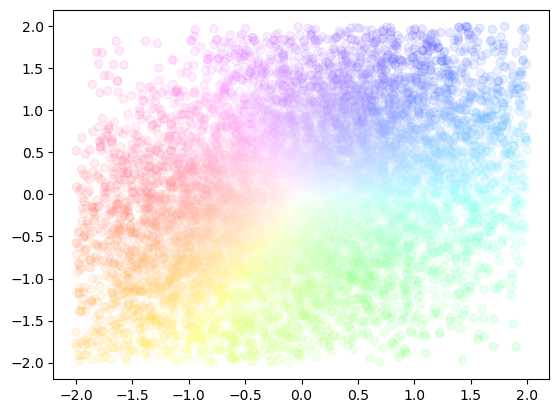

In [16]:
fig, ax = plt.subplots()

ax.scatter(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)

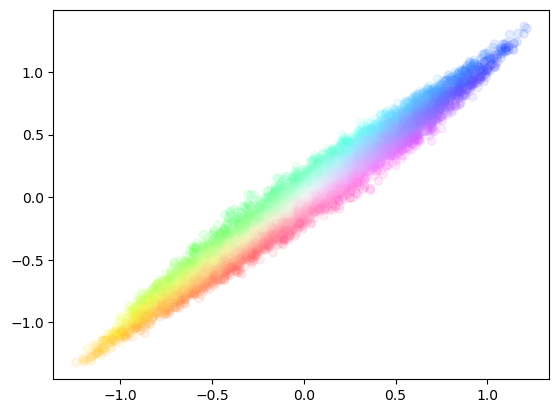

In [17]:
# Select bounded samples in observation space
samples_bounded = samples_plot[0][indices]

# Push forward thorugh learned bottleneck function
bn_samples_learned = estimated_bn_fcts[0, 1](samples_bounded)

fig, ax = plt.subplots()

ax.scatter(bn_samples_learned[:, 0], bn_samples_learned[:, 1], c=get_rgb_color(bn_samples_bounded[:, 0], bn_samples_bounded[:, 1]), alpha=0.1)

In [18]:
# Sanity check: calculate id metric
estimated_bn_samples_matrix = np.empty_like(estimated_bn_fcts, dtype=object)
estimated_bn_samples_matrix[0, 1] = estimated_bn_samples
eval_matrix = linear_bottleneck_eval(estimated_bn_samples_matrix, bn_samples)

print(np.mean(eval_matrix[eval_matrix != None]))

0.9897463903633832


In [ ]:
def id_viz(seed, mode='linear'):
    """
    Defines a two node SCBM with given seed and mode (linear or non-linear), visualized learned and ground-truth bottleneck spaces
    in order to show the learned map between the two. Ideally we want to see an invertible map. 
    """

## Nonlinear

In [ ]:
# Define two node SCBM

# Shared vars
n_micro = 4  # nr of internal nodes

M = np.ones((n_micro, n_micro))  # internal node sparsity mask
M[0,3] = M[1,2] = M[2,1] = M[3,0] = 0

# Node 1
P1 = sample_mrf_prec(dim=n_micro, M=M, rs=rs)  # precision matrix
mech1 = GaussianLangevinMechanism(mu=np.zeros(n_micro), E=np.linalg.inv(P1))

X1 = MacroCausalVar(parents=None, bottleneck_fcts=None, mechanism=mech1, d=n_micro)

# Node 2
P2 = sample_mrf_prec(dim=n_micro, M=M, rs=rs)  # precision matrix

# Sample linear bottleneck function
d_bottleneck = 2
w_bn = rs.uniform(size=(n_micro, d_bottleneck))
# Make sure rank is correct
while np.linalg.matrix_rank(w_bn) < d_bottleneck:
    w_bn = rs.uniform(size=(n_micro, d_bottleneck))

def f_bn(x):
    return x @ w_bn

# Sample linear mechanism function
w_mech = rs.uniform(size=(d_bottleneck, n_micro))
while np.linalg.matrix_rank(w_mech) < d_bottleneck:
    w_mech = rs.uniform(size=(d_bottleneck, n_micro))

def f_mech(x):
    return x @ w_mech

mech2 = GaussianLangevinMechanism(mu=f_mech, E=np.linalg.inv(P2))

X2 = MacroCausalVar(parents=[X1], bottleneck_fcts=[f_bn], mechanism=mech2, d=n_micro)

variables = np.empty(2, dtype=object)
variables[0] = X1
variables[1] = X2

A = np.asarray([[0, 1],
                [0, 0]])
d_bottleneck_matrix = np.empty_like(A, dtype=object)
d_bottleneck_matrix[0, 1] = 2

scbm = SCBM(variables=variables, A=A, d_bottleneck_matrix=d_bottleneck_matrix, seed=seed)

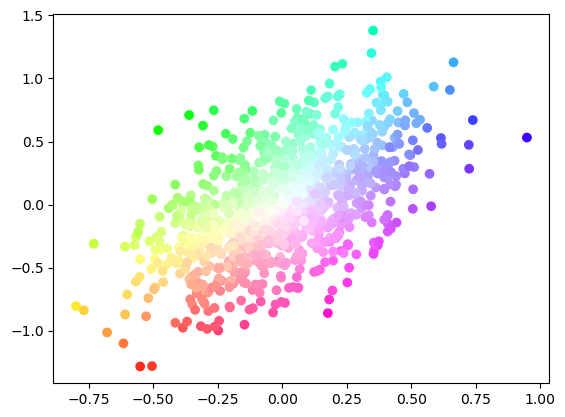

In [9]:
fig, ax = plt.subplots()

ax.scatter(estimated_bn_samples[:, 0], estimated_bn_samples[:, 1], c=get_rgb_color(bn_samples[0, 1][:, 0], bn_samples[0, 1][:, 1]))

plt.show()